In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [2]:
def fct(x,b):
    a=0.65
    y=1+a*x+b*x**2
    return y


def fit_func_normalized(x,b) :
    #integral=scipy.integrate.quad(lambda x: fct(x,a,b), x_min, x_max)[0]
    integral= (2 * (1 + b / 3))
    y=fct(x,b)/integral
    return y


def neg_ln_likelihood(array,b):
    llh=0
    for x in array:
        llh=-np.log(fit_func_normalized(x, b))+llh
    return llh



Text(0.5, 1.0, 'Histogram of read data')

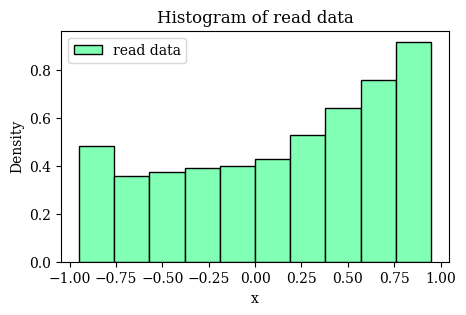

In [3]:
df = pd.read_csv('ParameterEstimation_Ex1.txt',header=None, names=['x'])
x_min = df["x"].min()
x_max = df["x"].max()

fig,ax=plt.subplots(1)
ax.hist(df["x"], bins=10, range=(x_min, x_max), density=True,color=my_cmap(0.5), edgecolor='black',rwidth=1,label="read data")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Histogram of read data")


## Beginning with analysing


In [4]:

print(neg_ln_likelihood(df["x"],b=1000))

4018.0171757356834


Minimum Negative Log-Likelihood: 1985.701960227527 at b=0.4444444444444445


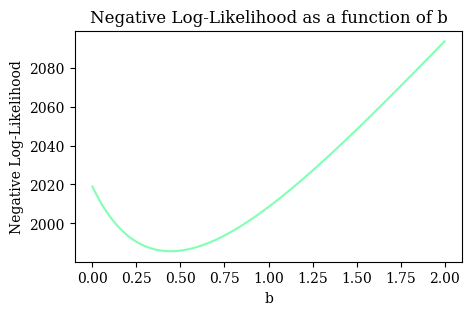

In [ ]:
#likelihood of read data_points for given distribution
llh_array=[]
b=np.linspace(0,2,100)
for i in b:
    llh=neg_ln_likelihood(df["x"],b=i)
    llh_array.append(llh)

fig,ax=plt.subplots(1)
ax.plot(b,llh_array,color=my_cmap(0.5), label="Negative Log-Likelihood")
ax.set_xlabel("b")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Negative Log-Likelihood as a function of b")
print(f"Minimum Negative Log-Likelihood: {min(llh_array)} at b={b[np.argmin(llh_array)]}")

## Exercise 1

In [6]:
#define starting values for fit parameters a and b, and perform fit using Minuit
b_min=0.25
b_max=0.75

mfit = Minuit(lambda b: neg_ln_likelihood(df["x"], b), b=b_min)
    
mfit.migrad()



┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1986                       │              Nfcn = 21               │
│ EDM = 3.76e-08 (Goal: 0.0002)    │            time = 0.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b    │   0.44    │   0.10    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────┐
│   │       b │
├───┼─────────┤
│ b │ 0.00921 │
└───┴─────────┘

In [ ]:
def find_confidence_interval(data_array, mfit, b_min, b_max,conf_factor=1):
    """Find the 68% confidence interval for the parameter b based on the negative log-likelihood function.
    Args:
        data_array (np.array): Array containing the data points.
        mfit (Minuit): Minuit object containing the fit results.
        b_min (float): Minimum value of b to consider for the confidence interval.
        b_max (float): Maximum value of b to consider for the confidence interval.
        conf_factor (float): The factor to multiply the difference in log-likelihood by to define the confidence interval (default is 1 for 68%).
    Returns:
        tuple: (b_minus, b_plus) where b_minus is the lower bound and b_plus is the upper bound of the 68% confidence interval for b.
    """
    min_llh = neg_ln_likelihood(data_array, mfit.values["b"])
    b_values = np.linspace(b_min, b_max, 1000)

    b_minus=b_min
    b_plus=b_min
    for b_val in b_values:
        if abs(neg_ln_likelihood(data_array, b_val) - min_llh)*2 < conf_factor:
            if b_minus == b_min:
                b_minus = b_val
            b_plus = b_val
            #print(f"b value within 68% confidence interval: {b_val}")
    print(f"68% confidence interval for b: [{b_minus}, {b_plus}]")

    return b_minus, b_plus



b_minus, b_plus = find_confidence_interval(df["x"], mfit, b_min, b_max)

68% confidence interval for b: [0.3781281281281281, 0.5137637637637638]


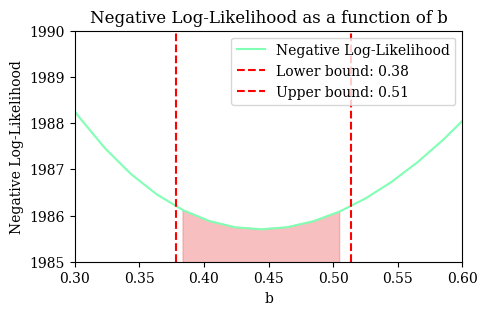

In [8]:
"""plot and mark the confidence interval on the plot of negative log-likelihood as a function of b
fill the area between the confidence interval with a different color to visually indicate the confidence interval"""

ax.axvline(b_minus, color='red', linestyle='--', label=f"Lower bound: {b_minus:.2f}")
ax.axvline(b_plus, color='red', linestyle='--', label=f"Upper bound: {b_plus:.2f}")
ax.fill_between(b, llh_array, where=(b >= b_minus) & (b <= b_plus), color='lightcoral', alpha=0.5)
ax.legend()
ax.set_xlabel("b")
ax.set_ylabel("Negative Log-Likelihood")
ax.set_title("Negative Log-Likelihood as a function of b")
ax.set_xlim(0.3,0.6)
ax.set_ylim(1985, 1990)
ax.plot(b_minus)
fig